# Pathway from NHE6 to GTP active site

Define the diffusion pathway from D260 (D292' in rotated.pdb) in NHE6 to H207 (H207') in TBC1D5/Ras7. 

## packages

In [1]:
import pathlib
import MDAnalysis as mda
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

## data

In [ ]:
castpdb = pathlib.Path("hollow.pdb")
model = pathlib.Path("../model_processing/rotated.pdb")

casting = mda.Universe(castpdb, to_guess=[])
u = mda.Universe(model)
protein = u.select_atoms("protein")


/Users/oliver/miniforge3/envs/mda314/lib/python3.14/site-packages/MDAnalysis/topology/PDBParser.py:376: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


## Methods
Find a minimum length path the quick and dirty way, using the hollow casting

1. generate a nearest + 2nd nearest neighbor graph from the casting sphere centers
2. select the points nearest to D260 (A:D292') and H207 (C:H207') – primed are local in rotated.pdb, unprimed are canonical.
3. find the shortest path through the graph (eg using Dijkstra's algorithm)
4. export the points on the path

In [3]:
casting.atoms.positions.shape

(47003, 3)

### Choice of cutoff for nearest neighbors

To get a sense of a good distance for nearest neighbors, calculate the RDF and find where the minimum after the 1st peak is.

In [5]:
from MDAnalysis.analysis import rdf

In [6]:
RDF = rdf.InterRDF(casting.atoms, casting.atoms, norm="none", range=(0, 6), nbins=120).run(verbose=True)

  0%|          | 0/1 [00:00<?, ?it/s]

/Users/oliver/anaconda3/envs/mda311/lib/python3.11/site-packages/MDAnalysis/analysis/base.py:542: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time


Text(0.5, 0, 'distance (Å)')

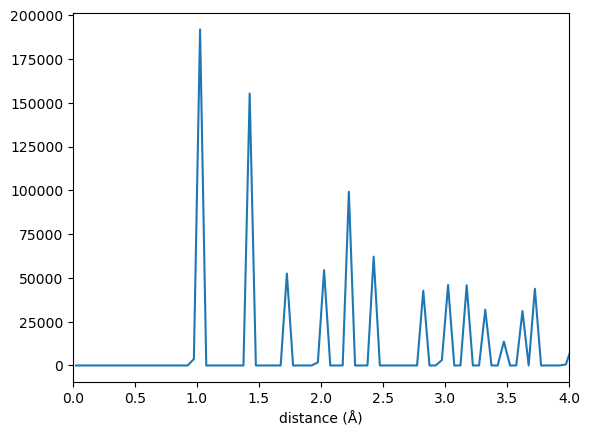

In [7]:
dV = 4/3*np.pi*(RDF.results.edges[1:]**3 - RDF.results.edges[:-1]**3)
N = RDF.results.count.copy()
N[0] = 0
plt.plot(RDF.results.bins, N/dV)
plt.xlim(0, 4)
plt.xlabel("distance (Å)")

From the plot, a cutoff of 1.3 for nearest neighbors and 1.5 for second nearest looks reasonable.

### Graph

Find points within cutoff distance via the fast `capped_distance` function:

In [8]:
edges = mda.lib.distances.capped_distance(casting.atoms, casting.atoms, max_cutoff=1.5, return_distances=False)

In [9]:
G = nx.Graph(edges.tolist())

In [10]:
G.number_of_nodes(), G.number_of_edges()

(47003, 210494)

### Source and sink nodes

* source: chain A, D260 (D292')
* sink: chain C, H207'


In [11]:
source = u.select_atoms("chainID A and resid 292")
sink = u.select_atoms("chainID C and resid 207")

print(source.residues)
print(sink.residues)

<ResidueGroup [<Residue ASP, 292>]>
<ResidueGroup [<Residue HIS, 207>]>


In [12]:
def find_closest_node(ag, nodepositions, max_cutoff=4):
    """Find index of closest node in G to ag"""
    return find_close_nodes(ag, nodepositions, max_cutoff=max_cutoff)[0]

def find_close_nodes(ag, nodepositions, max_cutoff=4):
    """Find indices of all nodes in G within max_cutoff to any atom in ag"""
    pairs, distances = mda.lib.distances.capped_distance(nodepositions, ag, max_cutoff=max_cutoff) 
    closest_nodes = pairs[np.argsort(distances)][:, 0]
    return closest_nodes

In [13]:
source_node = find_closest_node(source, casting.atoms)
sink_nodes = find_close_nodes(sink, casting.atoms, max_cutoff=9)
print(f"source = {source_node} ----> sink = {sink_nodes}")

source = 22167 ----> sink = [3737 3737 3294 3294 3737 2332 2332 6258]


### Find shortest path

In [28]:
def find_shortest_path(G, source_node, sink_nodes):
    paths = []
    for sink_node in sink_nodes:
        print(f"Pathfinding {source_node} ----> {sink_node}")
        try:
            p = nx.shortest_path(G, source=source_node, target=sink_node)
        except nx.NetworkXNoPath:
            print(f">> No path for {source_node} --/--> {sink_node}")
        else: 
            print(f">> FOUND path {source_node} ----> {sink_node} with length {len(p)}")
            paths.append(p)
    return paths

In [33]:
paths = find_shortest_path(G, source_node, sink_nodes)

Pathfinding 22167 ----> 3737
>> No path for 22167 --/--> 3737
Pathfinding 22167 ----> 3737
>> No path for 22167 --/--> 3737
Pathfinding 22167 ----> 3294
>> No path for 22167 --/--> 3294
Pathfinding 22167 ----> 3294
>> No path for 22167 --/--> 3294
Pathfinding 22167 ----> 3737
>> No path for 22167 --/--> 3737
Pathfinding 22167 ----> 2332
>> No path for 22167 --/--> 2332
Pathfinding 22167 ----> 2332
>> No path for 22167 --/--> 2332
Pathfinding 22167 ----> 6258
>> FOUND path 22167 ----> 6258 with length 69


In [34]:
[len(p) for p in paths]

[69]

### Export the path as PDB file

Paths are sorted by closest node to target so we'll take the one that gets us closest:

In [16]:
p = paths[0]

In [17]:
path_centers = casting.atoms[p]
path_centers.write("path.pdb")

/Users/oliver/anaconda3/envs/mda311/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:777: UserWarning: Unit cell dimensions not found. CRYST1 record set to unitary values.
  warnings.warn("Unit cell dimensions not found. "
/Users/oliver/anaconda3/envs/mda311/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'elements' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/Users/oliver/anaconda3/envs/mda311/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn("Found no information for attr: '{}'"


## Path

Length of path: sum the distances between path centers:

In [18]:
length = np.sum(np.linalg.norm(np.diff(path_centers.positions, axis=0), axis=1))
print(f"Approximate path length {length:.1f} Å")

Approximate path length 89.5 Å
